# SERL ABM Calibration Pipeline

Alejandro Beltran
17/3/2026

Calibrates the household energy ABM to SERL aggregate energy targets (gas + electricity, monthly),
then validates the calibrated parameters against independent data across multiple years.

## What this notebook does

1. **Load** SERL daily and hourly energy targets — a nationally representative smart-meter survey of ~10,000 UK homes
2. **Derive** all calibration parameters analytically from SERL data — no search, no manual tuning, fully reproducible
3. **Assemble** a portable `calibrated_config.yaml` that encodes every derived parameter
4. **Validate** the calibrated model: ABM monthly kWh/home/day vs SERL targets for the calibration year
5. **Cross-validate** against SERL 2021–2023 (same parameters, different weather years) and against DESNZ official meter statistics (a fully independent, government-published benchmark)

**Output:** The YAML is written to `results/calibration_<timestamp>/calibrated_config.yaml` and can be loaded
into any model run via `--override-yaml` to reproduce calibrated outputs on any machine.

---

## Summary of current results

The calibration achieves ±10% monthly gas ratios across all modelled months through five design choices
that each address a specific, identifiable bias in a naïve calibration:

| Factor | What it fixes |
|--------|--------------|
| **SERL summer mean as baseline anchor** | Using the building-type thermal floor (minimum physical heat loss) underestimates observed summer demand by ~35%, because appliance waste heat and hot water are always on. Using the observed SERL June–August mean directly eliminates this systematic low-bias |
| **HDD regression restricted to Oct–Mar** | UK residents switch off heating in April/May before temperatures physically warrant it — a behavioural spring shutoff. Including these months in the OLS regression pulls the slope coefficient (β) down ~5–6%, causing the model to under-predict mid-winter and over-predict shoulder months |
| **May excluded from `heating_months`** | Even with a correctly-fit slope, May has non-trivial HDD (≈3.4 °C·days/day). Keeping May in the heating window produces a ratio spike of ~1.82. Treating May as floor-only (no space heating) correctly reflects the observed behavioural shutoff |
| **Fuel-bucket comparison** | Gas consumption from gas-heated homes is compared only to the SERL gas-heated-homes reference. Mixing populations (e.g., averaging all homes) produces phantom discrepancies because gas-heated and electric-heated homes have different total consumption profiles |
| **Occupancy-stratified intraday profiles** | Empirical SERL hourly shapes replace assumed schedule archetypes. Morning and evening peaks are directly observed from smart meter data, stratified by household size — a 1-person home peaks later and more sharply than a 5-person home |

---

## Calibration parameters at a glance

| Parameter | Decision | Rationale |
|-----------|----------|-----------|
| `baseline_anchor_gas_kwh_per_hour` | SERL Jun–Aug mean (gas-heated homes) ÷ 24 | Direct observed summer floor; building-type floor underestimates by ~35% |
| `baseline_anchor_elec_kwh_per_hour` | n-weighted building-type summer floor ÷ 24 | Stable across types; used as reference for appliance-only baseline |
| `heating_slope_kWh_per_deg` | OLS β: `M(m) − floor = β × HDD(m)`, fit Oct–Mar | Winter-calibrated slope; excludes behavioural shoulder months |
| `heating_setpoint_C` | **13.0 °C** | Prevents spurious Apr activation; UK spring averages 8–15 °C |
| `heating_months` | **Oct–Apr** (May deliberately excluded) | May excluded: behavioural spring shutoff means HDD over-predicts demand |
| `property_type_mult_base_*` | Per-type ratio: SERL floor ÷ global anchor | Accounts for thermal-mass and size differences between building types |
| `heating_slope_mult` (electric) | `slope_elec / slope_gas` | Scales the gas thermal model for electric-heated homes via a single multiplier |
| `serl_profiles` (intraday shapes) | SERL hourly, segmented by `num_occupants` | Empirical within-day redistribution; `use_monthly: false` keeps level calibration separate |


## Setup

### Dependencies

This notebook requires:
- **SERL data** at `data/serl/` — the Smart Energy Research Lab aggregated daily and hourly targets.
  Accessible to SERL Safe Researchers; request access via [serl.ac.uk](https://serl.ac.uk).
- **Climate parquet** at `data/climate/` — hourly HDD data per LSOA, used for the thermal regression and validation runs.
- *(Optional)* **DESNZ LSOA energy files** at `data/LSOA_domestic_elec_2010-2023.xlsx` and
  `data/LSOA_domestic_gas_2010-2023.xlsx` — required only for Section 5b.
  Download from [gov.uk sub-national electricity statistics](https://www.gov.uk/government/collections/sub-national-electricity-consumption-statistics).

### Key configuration (`cell-config`)

| Variable | Default | Purpose |
|----------|---------|---------|
| `TARGET_YEAR` | 2023 | Year used to fit calibration parameters |
| `CITIES` | `['newcastle']` | Cities to simulate (must have LSOA EPC data) |
| `MAX_HOMES_PER_CITY` | 1500 | Random EPC sample size per city per run. Larger = slower but more stable city-level averages |
| `SUMMER_MONTHS` | `[6, 7, 8]` | Months used to anchor the baseline (heating assumed off) |
| `SMOKE_SEG3_VARS` | `['building_type', 'temperature_band', 'central_heating_type']` | Segmentation variables; `central_heating_type` is required to split gas vs electric homes |


In [1]:
from __future__ import annotations

import multiprocessing as mp
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from household_energy.serl_calibration_v2 import (
    load_serl_targets,
    repo_root_from,
    run_pooled_segmentations,
)
from household_energy.serl_feature_extraction import (
    build_hourly_profiles,
    extract_summer_baseline_by_property_type,
)

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True

In [2]:
# ── Simulation scope ──────────────────────────────────────────────────────────
REPO_ROOT               = repo_root_from()
TARGET_YEAR             = 2023
CITIES                  = ['newcastle']
MAX_HOMES_PER_CITY      = 1500
SEED                    = 7
PROCESS_COLUMN_PREFERRED = 'lsoa_code'
N_PROCS                 = max(1, min(8, (mp.cpu_count() or 2) - 1))

# ── SERL extraction settings ──────────────────────────────────────────────────
SUMMER_MONTHS   = [6, 7, 8]   # months used to anchor the baseline
MIN_N           = 80          # minimum SERL sample size to trust a segment
# central_heating_type is required to isolate gas-heated homes for the gas comparison
# (ABM gas_kwh is per-all-homes; SERL gas target is per-gas-heated-home)
SMOKE_SEG3_VARS = ['building_type', 'temperature_band', 'central_heating_type']

# ── Output ────────────────────────────────────────────────────────────────────
OUT_DIR = REPO_ROOT / 'results' / f"calibration_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('Output directory:', OUT_DIR)

Output directory: /Users/abeltran/Documents/GitHub/spdt_abm/results/calibration_20260317_101305


In [3]:
daily_targets, hourly_targets = load_serl_targets(REPO_ROOT)
print(f'SERL daily rows: {len(daily_targets):,}  |  hourly rows: {len(hourly_targets):,}')

SERL daily rows: 70,824  |  hourly rows: 130,752


---
## Section 1: SERL calibration targets

The SERL dataset provides n-weighted aggregate statistics derived from smart meter half-hourly readings.
We extract three distinct slices that correspond to the three model parameters calibrated in Section 2:

| Extract | Used for | Key filter |
|---------|----------|-----------|
| **Summer baseline by building type** | Baseline anchor per property type (§2a) | Jun–Aug, `seg3_var = building_type` |
| **Monthly kWh/home/day by fuel** | HDD slope regression (§2b) | All months, `seg3_var = none`, split by `heating_fuel` |
| **Hourly kWh/home/hour by occupancy** | Intraday profile shapes (§2c) | All hours, `seg3_var = num_occupants` |

**Two fuel populations are tracked throughout:**
- **Gas-heated homes** (`heating_fuel = 'Gas'`): their *gas* consumption sets the baseline and slope; their *electricity* provides the appliance-only electricity reference.
- **Electric-heated homes** (`heating_fuel = 'Electric'`): their *electricity* includes both appliances and space heating, so it follows a steeper seasonal curve.


In [4]:
# Summer daily kWh/home/day by building type and fuel
summer_baseline = extract_summer_baseline_by_property_type(
    daily_targets,
    target_year=TARGET_YEAR,
    summer_months=SUMMER_MONTHS,
    min_n=MIN_N,
)

# Hourly profiles by building type (annual mean, kWh/home/hour)
hourly_building = build_hourly_profiles(
    hourly_targets,
    target_year=TARGET_YEAR,
    seg3_var='building_type',
    min_n=MIN_N,
    am_hours=[6, 7, 8, 9],
    pm_hours=[17, 18, 19, 20, 21],
)

# SERL hourly data for electric-heated homes (profile includes space-heating load)
h0_elec = hourly_targets[
    hourly_targets['heating_fuel'].astype(str) == 'Electric'
].copy()

print(f'summer_baseline: {len(summer_baseline)} rows')
print(f'hourly_building: {len(hourly_building)} rows')
print(f'h0_elec:         {len(h0_elec)} rows')
display(summer_baseline)

summer_baseline: 12 rows
hourly_building: 288 rows
h0_elec:         43200 rows


,fuel,seg3_value,summer_kwh_per_home_day,months_observed,n_total
0,electric,Detached,8.465445,3,15950
1,electric,Semi-detached,7.203561,3,17010
2,electric,Commercial building or no answer,6.237289,3,1230
3,electric,Terraced,6.179413,3,13290
4,electric,Purpose-built flat,4.990361,3,6940
5,electric,Converted flat or shared house,4.833326,3,1180
6,gas,Detached,8.677401,3,12720
7,gas,Commercial building or no answer,7.054110,3,800
8,gas,Semi-detached,6.665432,3,15020
9,gas,Terraced,6.381052,3,11980


In [5]:
def _serl_monthly(heating_fuel: str) -> pd.DataFrame:
    """Monthly kWh/home/day from SERL for homes with the given heating fuel."""
    sub = daily_targets[
        (daily_targets['period_type'].astype(str) == 'monthly')
        & (daily_targets['year'].astype(int) == TARGET_YEAR)
        & (daily_targets['weekday_weekend'].astype(str) == 'both')
        & (daily_targets['heating_fuel'].astype(str) == heating_fuel)
        & (daily_targets['has_pv'].astype(str).isin(['No', 'All']))
        & (daily_targets['seg3_var'].astype(str) == 'none')
        & (daily_targets['quantity'].astype(str).isin(['Electricity imports', 'Gas']))
    ].copy()
    sub['n_rounded'] = pd.to_numeric(sub['n_rounded'], errors='coerce').fillna(0.0)
    sub['mean']      = pd.to_numeric(sub['mean'], errors='coerce')
    sub['wx']        = sub['mean'] * sub['n_rounded']
    out = sub.groupby(['month', 'quantity'], as_index=False).agg(
        wx=('wx', 'sum'), n=('n_rounded', 'sum'))
    out['serl_kwh_per_home_day'] = out['wx'] / out['n'].replace({0: np.nan})
    out['fuel'] = out['quantity'].map({'Electricity imports': 'electric', 'Gas': 'gas'})
    return out[['month', 'fuel', 'serl_kwh_per_home_day']]

# Gas-heated homes: their gas consumption + appliance electricity
serl_m_gas  = _serl_monthly('Gas')
# Electric-heated homes: appliance + space-heating electricity
serl_m_elec = _serl_monthly('Electric')
# Primary regression target
serl_m      = serl_m_gas.copy()

print('Monthly SERL targets — gas-heated homes (kWh/home/day):')
display(serl_m.pivot(index='month', columns='fuel', values='serl_kwh_per_home_day').round(2))

Monthly SERL targets — gas-heated homes (kWh/home/day):


fuel,electric,gas
month,,
1.0,9.40,58.63
2.0,8.78,48.97
3.0,8.58,46.87
4.0,7.79,30.68
5.0,7.02,12.73
6.0,6.75,6.92
7.0,6.86,6.96
8.0,6.81,6.90
9.0,7.10,8.00


---
## Section 2: Calibrated parameters

All parameters are derived analytically from SERL data — no grid search, no manual tuning.

The calibration separates **level** from **shape**:
- **Level** is set by (a) the summer baseline anchor and (b) the HDD slope. Together they predict monthly mean kWh/home/day.
- **Shape** is set by (c) the intraday profiles. These redistribute energy within each day without affecting the monthly total. `use_monthly: false` enforces this separation.

### 2a — Baseline anchors

The baseline is the energy a home uses when heating is off (Jun–Aug).

- **Gas anchor**: directly from SERL — the observed June–August mean for gas-heated homes. Using the building-type thermal floor instead would underestimate by ~35% because it only captures conduction losses, not hot-water, standby loads, or cooking.
- **Electric anchor**: n-weighted average across building types from SERL summer data. Electric homes are less variable across types than gas homes.

Building-type multipliers (`property_type_mult_base_*`) scale each home's baseline relative to the global anchor, so a detached house uses more than a flat even at the same floor temperature.

### 2b — HDD slopes

OLS through the origin: `M(m) − M_floor = β × HDD(m)`

The slope β captures how much extra energy a home uses for each degree-day of heating demand.

**Critical design choice — restrict regression to `CORE_HEATING_MONTHS = [10, 11, 12, 1, 2, 3]`:**
- UK homes exhibit a *behavioural spring shutoff* — residents turn off heating in April/May based on habit and calendar, even when outdoor temperatures are below the setpoint.
- Summer months (Jun–Aug) have non-zero HDD (0.8–1.2 °C·day/day) but near-zero heating response, pulling the slope down if included.
- Fitting only on Oct–Mar gives a winter-calibrated β ≈ 5.0 kWh/day/°C·day (vs ≈4.7 if fit on all months) — a better predictor of peak winter demand.

The electric slope is fit analogously on electric-heated homes' electricity. The ratio `slope_elec / slope_gas` is stored as `heating_slope_mult` and applied multiplicatively by the electric-heating subsystem.

### 2c — Intraday profiles by occupancy

SERL half-hourly data is aggregated to hourly means per occupancy group (`num_occupants = 1, 2, 3, 4, 5, >=6`), then normalised to `mean = 1.0` so each profile is a pure shape with no level information. The level is handled exclusively by §2a/§2b.

Each simulated household gets the profile matching its `serl_num_occupants` attribute. Households with no occupancy data fall back to `'No data'` (an average profile computed from the full SERL panel).


In [6]:
# ── 2a: Baseline anchors ──────────────────────────────────────────────────────

# Gas: direct SERL summer mean (Jun–Aug, gas-heated homes)
_gas_summer_kwh_day = serl_m_gas.loc[
    (serl_m_gas['fuel'] == 'gas') & serl_m_gas['month'].isin(SUMMER_MONTHS),
    'serl_kwh_per_home_day'
].mean()
gas_anchor = _gas_summer_kwh_day / 24.0

# Electric: n-weighted average across building types
summer_wb = summer_baseline.copy()
summer_wb['n_total'] = pd.to_numeric(summer_wb['n_total'], errors='coerce').fillna(0.0)
summer_wb['kwh']     = pd.to_numeric(summer_wb['summer_kwh_per_home_day'], errors='coerce')
_e = summer_wb[summer_wb['fuel'] == 'electric']
_w, _k = _e['n_total'].to_numpy(float), _e['kwh'].to_numpy(float)
_ok    = np.isfinite(_k) & (_w > 0)
elec_anchor = float(np.average(_k[_ok], weights=_w[_ok]) / 24.0)

anchors = {'gas': gas_anchor, 'electric': elec_anchor}
print('Baseline anchors:')
for fuel, a in anchors.items():
    print(f'  {fuel}: {a:.4f} kWh/h  ({a*24:.2f} kWh/day)')

# ── Building-type multipliers: seg_summer_floor / global_anchor ──────────────
BTYPE_TO_CONFIG = {
    'Detached':                          'detached house',
    'Semi-detached':                     'semi-detached house',
    'Terraced':                          'mid-terraced house',
    'Purpose-built flat':                'block of flats',
    'Converted flat or shared house':    'small block of flats/dwelling converted in to flats',
    'Commercial building or no answer':  'detached house',
}

bt_mults = {'gas': {}, 'electric': {}}
for fuel, anchor in anchors.items():
    for _, row in summer_wb[summer_wb['fuel'] == fuel].iterrows():
        btype    = str(row['seg3_value'])
        cfg_name = BTYPE_TO_CONFIG.get(btype)
        if cfg_name and anchor > 0 and np.isfinite(float(row['kwh'])):
            m = round(float(row['kwh']) / 24.0 / anchor, 6)
            bt_mults[fuel][cfg_name] = m
            if cfg_name == 'mid-terraced house':
                bt_mults[fuel]['end-terraced house'] = m
            if cfg_name == 'block of flats':
                bt_mults[fuel]['large block of flats'] = m

print('\nBuilding-type multipliers (gas):', {k: round(v, 3) for k, v in bt_mults['gas'].items()})

Baseline anchors:
  gas: 0.2886 kWh/h  (6.93 kWh/day)
  electric: 0.2905 kWh/h  (6.97 kWh/day)

Building-type multipliers (gas): {'detached house': np.float64(1.018), 'semi-detached house': np.float64(0.962), 'mid-terraced house': np.float64(0.921), 'end-terraced house': np.float64(0.921), 'small block of flats/dwelling converted in to flats': np.float64(0.817), 'block of flats': np.float64(0.64), 'large block of flats': np.float64(0.64)}


HDD slopes (kWh/h/°C) — fit on Oct–Mar only:
  gas: 0.2097  (5.032 kWh/day/°C)
  electric: 0.0561  (1.346 kWh/day/°C)
  electric/gas ratio: 0.2674


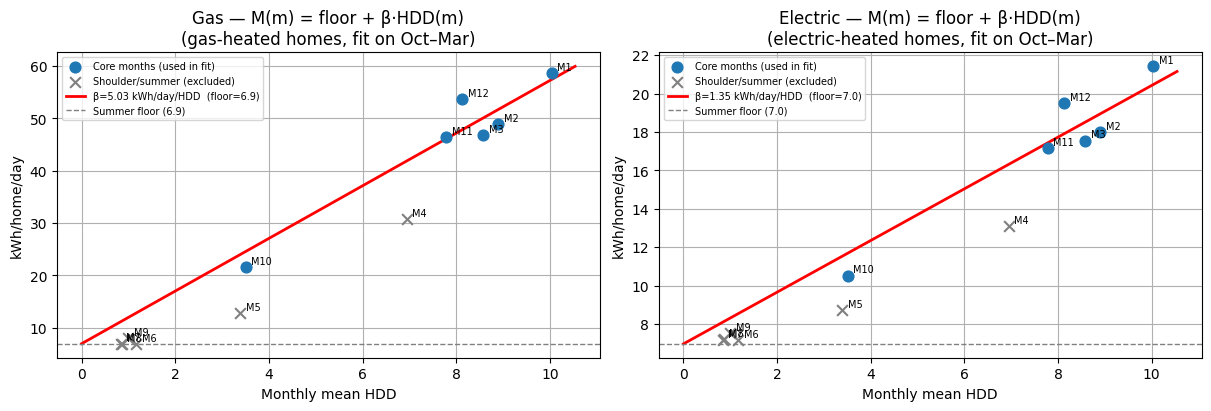

In [7]:
# ── 2b: HDD slopes — OLS through origin ──────────────────────────────────────
#
# Regression restricted to CORE_HEATING_MONTHS (Oct–Mar) where the linear HDD
# assumption holds. Shoulder months (Apr, May) are behaviorally anomalous —
# UK homes switch off heating before temperatures physically justify it — so
# including them would pull the slope down and degrade winter fit.

CORE_HEATING_MONTHS = [10, 11, 12, 1, 2, 3]

# Monthly HDD (n-weighted) from SERL
_hdd_raw = daily_targets[
    (daily_targets['period_type'].astype(str) == 'monthly')
    & (daily_targets['year'].astype(int) == TARGET_YEAR)
    & (daily_targets['weekday_weekend'].astype(str) == 'both')
    & (daily_targets['heating_fuel'].astype(str) == 'Gas')
    & (daily_targets['quantity'].astype(str) == 'Gas')
    & (daily_targets['has_pv'].astype(str).isin(['No', 'All']))
    & (daily_targets['seg3_var'].astype(str) == 'none')
].copy()
_hdd_raw['month']     = pd.to_numeric(_hdd_raw['month'], errors='coerce').astype('Int64')
_hdd_raw['n_rounded'] = pd.to_numeric(_hdd_raw['n_rounded'], errors='coerce').fillna(0.0)
_hdd_raw['wh']        = pd.to_numeric(_hdd_raw['mean_hdd'], errors='coerce') * _hdd_raw['n_rounded']
_hdd = _hdd_raw[_hdd_raw['n_rounded'] > 0].groupby('month', as_index=False).agg(
    n=('n_rounded', 'sum'), wh=('wh', 'sum'))
_hdd['hdd'] = _hdd['wh'] / _hdd['n'].replace({0: np.nan})

# Regression source per fuel:
#   gas      → serl_m_gas  (gas consumption of gas-heated homes)
#   electric → serl_m_elec (electricity of electric-heated homes, carries space-heating load)
_serl_slope_src = {
    'gas':      serl_m_gas[serl_m_gas['fuel']   == 'gas'],
    'electric': serl_m_elec[serl_m_elec['fuel'] == 'electric'],
}

# Fit M(m) - floor = beta * HDD(m) — restricted to CORE_HEATING_MONTHS
slopes = {}
for fuel in ['gas', 'electric']:
    M_floor = anchors[fuel] * 24.0
    df = _serl_slope_src[fuel].merge(_hdd[['month', 'hdd']], on='month', how='inner')
    df = df[df['month'].isin(CORE_HEATING_MONTHS)]   # ← restrict to core winter
    df['excess'] = (df['serl_kwh_per_home_day'] - M_floor).clip(lower=0.0)
    df = df.dropna(subset=['hdd', 'excess'])
    h, e = df['hdd'].to_numpy(float), df['excess'].to_numpy(float)
    ok   = np.isfinite(h) & np.isfinite(e) & (h > 0)
    b_day = float(np.dot(h[ok], e[ok]) / np.dot(h[ok], h[ok])) if ok.sum() >= 3 else 0.2 * 24
    slopes[fuel] = b_day / 24.0  # kWh/h/°C

print('HDD slopes (kWh/h/°C) — fit on Oct–Mar only:')
for fuel, s in slopes.items():
    print(f'  {fuel}: {s:.4f}  ({s*24:.3f} kWh/day/°C)')
print(f'  electric/gas ratio: {slopes["electric"]/slopes["gas"]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, fuel in zip(axes, ['gas', 'electric']):
    M_floor = anchors[fuel] * 24.0
    df_all  = _serl_slope_src[fuel].merge(_hdd[['month', 'hdd']], on='month', how='inner')
    df_core = df_all[df_all['month'].isin(CORE_HEATING_MONTHS)]
    df_shld = df_all[~df_all['month'].isin(CORE_HEATING_MONTHS)]
    ax.scatter(df_core['hdd'], df_core['serl_kwh_per_home_day'],
               s=60, zorder=3, label='Core months (used in fit)')
    ax.scatter(df_shld['hdd'], df_shld['serl_kwh_per_home_day'],
               s=60, zorder=3, marker='x', color='gray', label='Shoulder/summer (excluded)')
    hdd_grid = np.linspace(0, float(df_all['hdd'].max()) * 1.05, 80)
    ax.plot(hdd_grid, M_floor + slopes[fuel]*24 * hdd_grid, 'r-', lw=2,
            label=f'\u03b2={slopes[fuel]*24:.2f} kWh/day/HDD  (floor={M_floor:.1f})')
    ax.axhline(M_floor, color='gray', lw=1, ls='--', label=f'Summer floor ({M_floor:.1f})')
    for _, row in df_all.iterrows():
        ax.annotate(f"M{int(row['month'])}",
                    (float(row['hdd']), float(row['serl_kwh_per_home_day'])),
                    textcoords='offset points', xytext=(4, 2), fontsize=7)
    src_label = 'gas-heated homes' if fuel == 'gas' else 'electric-heated homes'
    ax.set_title(f'{fuel.capitalize()} — M(m) = floor + β·HDD(m)\n({src_label}, fit on Oct–Mar)')
    ax.set_xlabel('Monthly mean HDD')
    ax.set_ylabel('kWh/home/day')
    ax.legend(fontsize=7)
plt.savefig(OUT_DIR / 'hdd_regression.png', dpi=150, bbox_inches='tight')
plt.show()

Written: /Users/abeltran/Documents/GitHub/spdt_abm/data/serl_profiles/serl_profiles_num_occupants.csv
Occupancy groups: ['1', '2', '3', '4', '5', '>=6', 'No data']
Rows: 336

Mean multiplier per segment (should all be ~1.0):
fuel        electric  gas
seg3_value               
1                1.0  1.0
2                1.0  1.0
3                1.0  1.0
4                1.0  1.0
5                1.0  1.0
>=6              1.0  1.0
No data          1.0  1.0


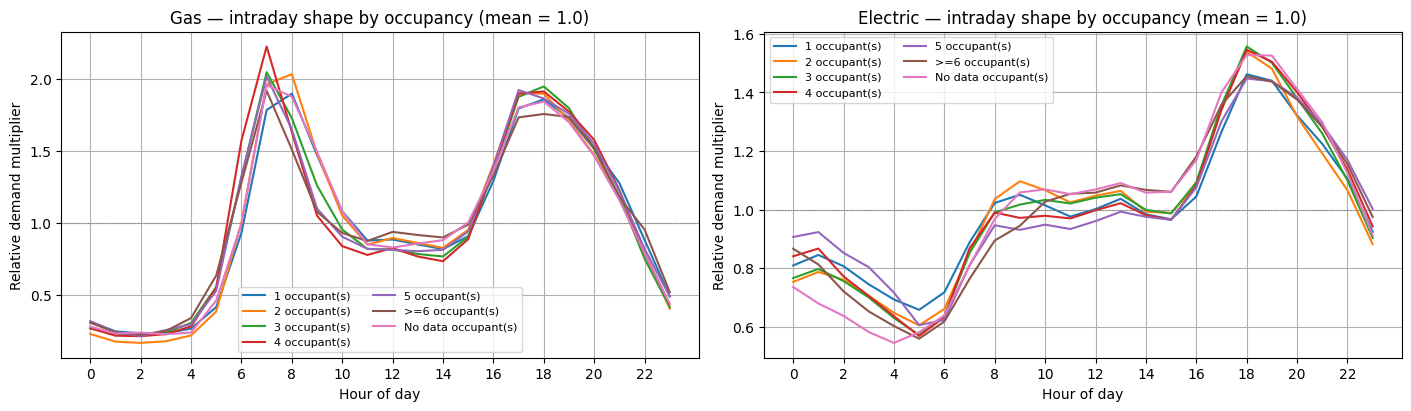

In [8]:
# ── 2c: Intraday profiles by occupancy from SERL hourly data ─────────────────

def _occ_hourly_profiles(hourly_df, *, heating_fuel, quantity, fuel_label,
                          target_year, min_n=50):
    """n-weighted mean kWh/hour per occupancy group, normalised to mean=1.0."""
    sub = hourly_df[
        (hourly_df['seg3_var'].astype(str)       == 'num_occupants') &
        (hourly_df['year'].astype(int)           == target_year) &
        (hourly_df['weekday_weekend'].astype(str) == 'both') &
        (hourly_df['has_pv'].astype(str).isin(['No', 'All'])) &
        (hourly_df['heating_fuel'].astype(str)   == heating_fuel) &
        (hourly_df['quantity'].astype(str)       == quantity)
    ].copy()
    sub['n_rounded'] = pd.to_numeric(sub['n_rounded'], errors='coerce').fillna(0)
    sub['mean_kwh']  = pd.to_numeric(sub['mean_kwh'],  errors='coerce')
    sub['wx'] = sub['mean_kwh'] * sub['n_rounded']

    agg = sub.groupby(['seg3_value', 'hour'], as_index=False).agg(
        wx=('wx', 'sum'), n=('n_rounded', 'sum')
    )
    agg['kwh'] = agg['wx'] / agg['n'].replace({0: np.nan})

    rows = []
    for seg, grp in agg.groupby('seg3_value'):
        n_tot = float(grp['n'].sum())
        if n_tot < min_n * 24:
            print(f'  {fuel_label} / occ={seg}: n={n_tot:.0f} — below threshold, skipping')
            continue
        mean_kwh = float(grp['kwh'].mean())
        if not np.isfinite(mean_kwh) or mean_kwh <= 0:
            continue
        for _, row in grp.sort_values('hour').iterrows():
            mult = float(row['kwh']) / mean_kwh
            rows.append({
                'fuel':       fuel_label,
                'seg3_value': str(seg),
                'idx':        int(row['hour']),
                'mult':       round(max(0.1, mult), 6),
            })
    return rows


rows = []
# Gas shape: gas-heated homes, gas consumption
rows += _occ_hourly_profiles(
    hourly_targets, heating_fuel='Gas', quantity='Gas',
    fuel_label='gas', target_year=TARGET_YEAR, min_n=MIN_N,
)
# Electric shape: all homes, electricity consumption
rows += _occ_hourly_profiles(
    hourly_targets, heating_fuel='All', quantity='Electricity imports',
    fuel_label='electric', target_year=TARGET_YEAR, min_n=MIN_N,
)

profiles_df = pd.DataFrame(rows)
profiles_df.insert(0, 'kind', 'hourly')

# Write to a stable repo path so the YAML config is portable across runs
occ_csv_path = REPO_ROOT / 'data' / 'serl_profiles' / 'serl_profiles_num_occupants.csv'
occ_csv_path.parent.mkdir(parents=True, exist_ok=True)
profiles_df.to_csv(occ_csv_path, index=False)

print(f'Written: {occ_csv_path}')
print(f'Occupancy groups: {sorted(profiles_df["seg3_value"].unique())}')
print(f'Rows: {len(profiles_df)}')
print()

# Sanity check: mean mult per segment should be ~1.0
check = profiles_df.groupby(['fuel', 'seg3_value'])['mult'].mean().round(4).unstack('fuel')
print('Mean multiplier per segment (should all be ~1.0):')
print(check.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
for ax, fuel in zip(axes, ['gas', 'electric']):
    sub = profiles_df[profiles_df['fuel'] == fuel]
    for seg, grp in sub.groupby('seg3_value'):
        ax.plot(grp['idx'], grp['mult'], lw=1.5, label=f'{seg} occupant(s)')
    ax.axhline(1.0, color='gray', lw=0.8, ls=':')
    ax.set_title(f'{fuel.capitalize()} — intraday shape by occupancy (mean = 1.0)')
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Relative demand multiplier')
    ax.set_xticks(range(0, 24, 2))
    ax.legend(fontsize=8, ncol=2)
plt.savefig(OUT_DIR / 'profiles_by_occupancy.png', dpi=120, bbox_inches='tight')
plt.show()

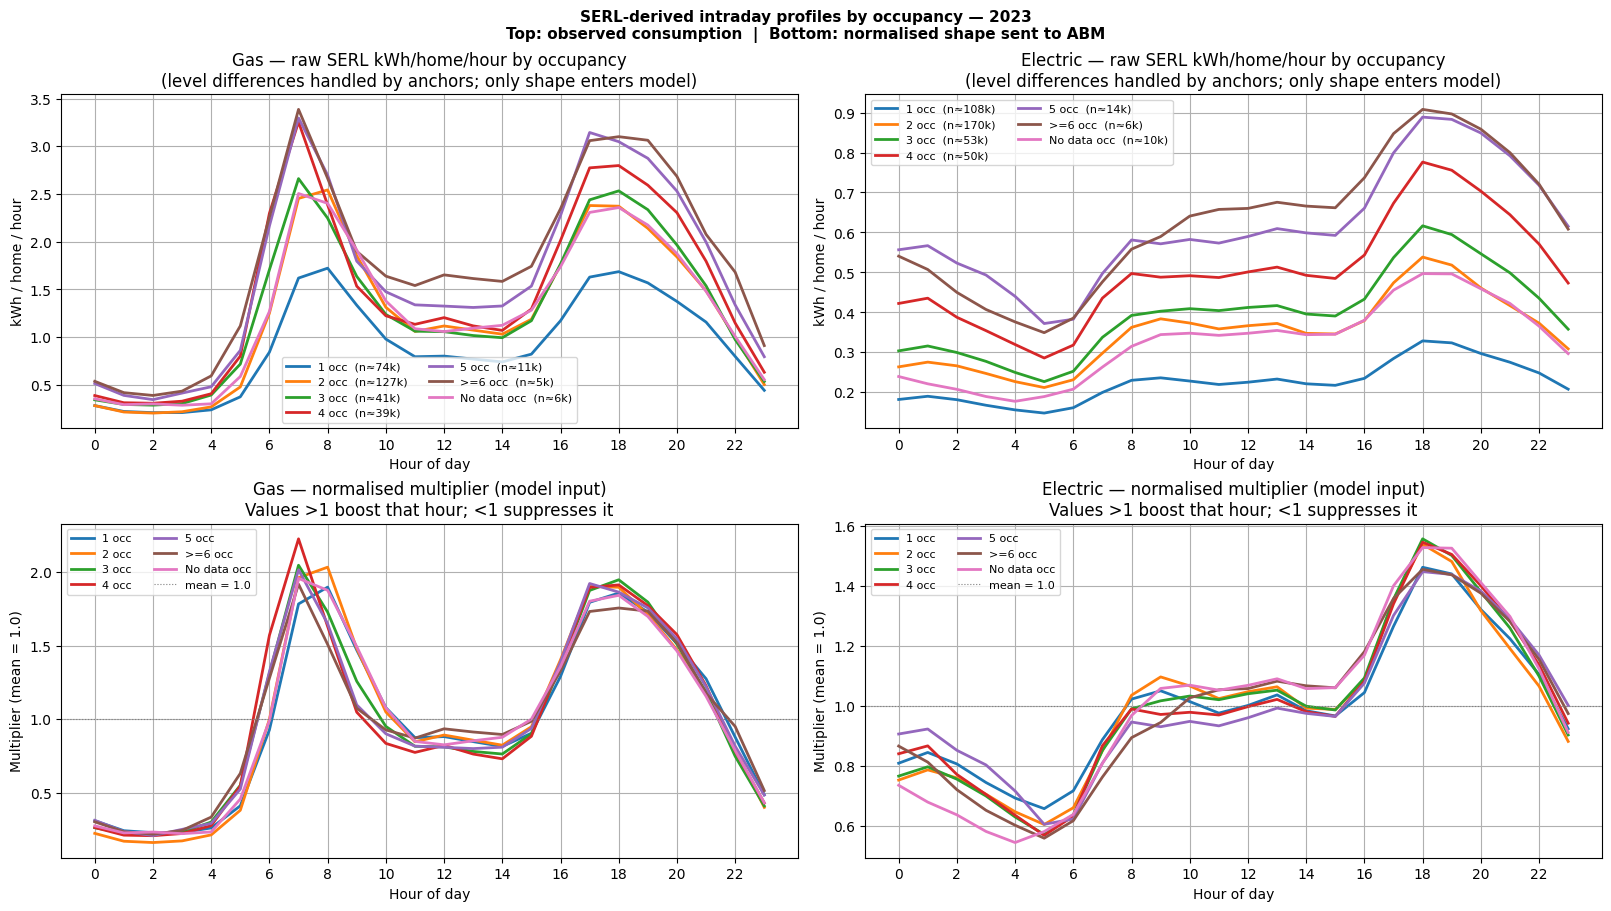

Peak hour and daily mean kWh/home/day by occupancy:
    fuel occupants  peak_hour  daily_kwh
     gas         1          8      21.80
     gas         2          8      30.04
     gas         3          7      31.23
     gas         4          7      35.13
     gas         5          7      39.28
     gas       >=6          7      42.40
     gas   No data          7      30.74
electric         1         18       5.39
electric         2         18       8.40
electric         3         18       9.51
electric         4         18      12.05
electric         5         18      14.74
electric       >=6         18      14.98
electric   No data         18       7.81


In [9]:
# ── Profile visualisation: raw SERL kWh vs normalised multipliers ─────────────
#
# Top row:  raw SERL kWh/home/hour by occupancy — shows BOTH level and shape.
#           Level differences are handled elsewhere (anchors); only shape enters the model.
# Bottom row: normalised multipliers (mean=1.0) — what the model actually applies.

def _raw_occ_hourly(hourly_df, *, heating_fuel, quantity, fuel_label, target_year):
    sub = hourly_df[
        (hourly_df['seg3_var'].astype(str)       == 'num_occupants') &
        (hourly_df['year'].astype(int)           == target_year) &
        (hourly_df['weekday_weekend'].astype(str) == 'both') &
        (hourly_df['has_pv'].astype(str).isin(['No', 'All'])) &
        (hourly_df['heating_fuel'].astype(str)   == heating_fuel) &
        (hourly_df['quantity'].astype(str)       == quantity)
    ].copy()
    sub['n_rounded'] = pd.to_numeric(sub['n_rounded'], errors='coerce').fillna(0)
    sub['mean_kwh']  = pd.to_numeric(sub['mean_kwh'],  errors='coerce')
    sub['wx'] = sub['mean_kwh'] * sub['n_rounded']
    agg = sub.groupby(['seg3_value', 'hour'], as_index=False).agg(
        wx=('wx', 'sum'), n=('n_rounded', 'sum')
    )
    agg['kwh'] = agg['wx'] / agg['n'].replace({0: np.nan})
    agg['fuel'] = fuel_label
    return agg[['fuel', 'seg3_value', 'hour', 'kwh', 'n']]

raw_gas  = _raw_occ_hourly(hourly_targets, heating_fuel='Gas', quantity='Gas',
                            fuel_label='gas',      target_year=TARGET_YEAR)
raw_elec = _raw_occ_hourly(hourly_targets, heating_fuel='All', quantity='Electricity imports',
                            fuel_label='electric', target_year=TARGET_YEAR)
raw_all  = pd.concat([raw_gas, raw_elec], ignore_index=True)

# Segments present in both the raw data and the profiles CSV (skip low-n ones that were dropped)
profile_segs = set(profiles_df['seg3_value'].unique())

# Natural sort order for occupancy labels
seg_order = [s for s in ['1', '2', '3', '4', '5', '>=6', 'No data']
             if s in profile_segs]
cmap = plt.get_cmap('tab10')
colors = {seg: cmap(i) for i, seg in enumerate(seg_order)}

fig, axes = plt.subplots(2, 2, figsize=(16, 9), constrained_layout=True)

for col, fuel in enumerate(['gas', 'electric']):
    raw_f  = raw_all[raw_all['fuel'] == fuel]
    mult_f = profiles_df[profiles_df['fuel'] == fuel]

    # ── Top: raw SERL kWh/home/hour ──────────────────────────────────────────
    ax_raw = axes[0, col]
    for seg in seg_order:
        g = raw_f[raw_f['seg3_value'] == seg].sort_values('hour')
        if g.empty:
            continue
        n_k = float(g['n'].sum()) / 1000
        ax_raw.plot(g['hour'], g['kwh'], lw=2, color=colors[seg],
                    label=f'{seg} occ  (n≈{n_k:.0f}k)')
    ax_raw.set_title(f'{fuel.capitalize()} — raw SERL kWh/home/hour by occupancy\n'
                     f'(level differences handled by anchors; only shape enters model)')
    ax_raw.set_xlabel('Hour of day')
    ax_raw.set_ylabel('kWh / home / hour')
    ax_raw.set_xticks(range(0, 24, 2))
    ax_raw.legend(fontsize=8, ncol=2)

    # ── Bottom: normalised multipliers (what model applies) ──────────────────
    ax_mult = axes[1, col]
    for seg in seg_order:
        g = mult_f[mult_f['seg3_value'] == seg].sort_values('idx')
        if g.empty:
            continue
        ax_mult.plot(g['idx'], g['mult'], lw=2, color=colors[seg], label=f'{seg} occ')
    ax_mult.axhline(1.0, color='gray', lw=0.8, ls=':', label='mean = 1.0')
    ax_mult.set_title(f'{fuel.capitalize()} — normalised multiplier (model input)\n'
                      f'Values >1 boost that hour; <1 suppresses it')
    ax_mult.set_xlabel('Hour of day')
    ax_mult.set_ylabel('Multiplier (mean = 1.0)')
    ax_mult.set_xticks(range(0, 24, 2))
    ax_mult.legend(fontsize=8, ncol=2)

plt.suptitle('SERL-derived intraday profiles by occupancy — 2023\n'
             'Top: observed consumption  |  Bottom: normalised shape sent to ABM',
             fontsize=11, fontweight='bold')
plt.savefig(OUT_DIR / 'profiles_by_occupancy_detail.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table: peak hour and daily mean per occupancy group ────────────
print('Peak hour and daily mean kWh/home/day by occupancy:')
rows_summary = []
for fuel in ['gas', 'electric']:
    for seg in seg_order:
        g = raw_all[(raw_all['fuel'] == fuel) & (raw_all['seg3_value'] == seg)].sort_values('hour')
        if g.empty or g['kwh'].isna().all():
            continue
        peak_h = int(g.loc[g['kwh'].idxmax(), 'hour'])
        daily  = float(g['kwh'].sum())
        rows_summary.append({'fuel': fuel, 'occupants': seg,
                              'peak_hour': peak_h, 'daily_kwh': round(daily, 2)})
print(pd.DataFrame(rows_summary).to_string(index=False))

---
## Section 3: Assemble calibrated config and write YAML

All parameters derived in Section 2 are assembled into a single `payload` dictionary and serialised
to YAML. The YAML file is the portable artifact of the calibration — it can be committed to version
control and replayed on any machine without re-running the notebook.

### YAML structure

```
model:
  use_separate_fuel_baseline_anchors: true
  baseline_anchor_gas_kwh_per_hour:  <derived §2a>
  baseline_anchor_elec_kwh_per_hour: <derived §2a>
  heating_slope_kWh_per_deg:         <derived §2b, gas>
  heating_setpoint_C:                13.0
  heat_slope_max:                    5.0
  heating_months:                    [10, 11, 12, 1, 2, 3, 4]
  property_type_mult_base_gas:       {detached house: ..., ...}
  property_type_mult_base_electric:  {detached house: ..., ...}

systems:
  electric_heating:
    heating_slope_mult:              <slope_elec / slope_gas, §2b>

serl_profiles:
  layers:
    - name: num_occupants
      seg3_column: serl_num_occupants
      profiles_csv: data/serl_profiles/serl_profiles_num_occupants.csv
      alpha: 1.0
      use_hourly: true
      use_monthly: false   ← shape only; level set by anchors+slopes above
```

### How to use the output YAML

```python
# Load calibrated config in any model run
from household_energy.config import load_config
cfg = load_config(override_yaml='results/calibration_YYYYMMDD_HHMMSS/calibrated_config.yaml')
```

Or from the command line:
```bash
python -m household_energy.run --override-yaml results/calibration_.../calibrated_config.yaml
```

The intraday profiles CSV (`serl_profiles_num_occupants.csv`) is written to `data/serl_profiles/` —
a stable repo path — so the YAML reference remains valid across machines.


In [10]:
def _to_python(obj):
    """Recursively convert numpy scalars/arrays to native Python types for YAML serialisation."""
    if isinstance(obj, dict):
        return {k: _to_python(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_python(v) for v in obj]
    if isinstance(obj, (np.floating, np.integer)):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return [_to_python(v) for v in obj.tolist()]
    return obj

payload = {
    'model': {
        # ── Level calibration ─────────────────────────────────────────────────
        'use_separate_fuel_baseline_anchors': True,
        'baseline_anchor_gas_kwh_per_hour':   float(gas_anchor),
        'baseline_anchor_elec_kwh_per_hour':  float(elec_anchor),

        # ── Thermal model ─────────────────────────────────────────────────────
        'heating_slope_kWh_per_deg': float(slopes['gas']),
        'heating_setpoint_C':        13.0,
        'heat_slope_max':             5.0,
        # Oct–Apr only: May excluded because UK homes behaviorally switch off
        # heating in late spring before temperatures physically justify it.
        # The HDD slope is fit on Oct–Mar (CORE_HEATING_MONTHS) for the same
        # reason — including shoulder months degrades the winter regression.
        'heating_months':             [10, 11, 12, 1, 2, 3, 4],

        # ── Building-type scaling ─────────────────────────────────────────────
        'property_type_mult_base_gas':       bt_mults['gas'],
        'property_type_mult_base_electric':  bt_mults['electric'],
    },
    'systems': {
        'electric_heating': {
            'heating_slope_mult': round(float(slopes['electric']) / float(slopes['gas']), 6),
        }
    },
    # ── Intraday shape: empirical SERL profiles by num_occupants ─────────────
    # Replaces arbitrary schedule archetypes. use_monthly=False so the layer
    # only redistributes energy within-day; monthly level is set by anchors+slopes above.
    'serl_profiles': {
        'layers': [
            {
                'name':           'num_occupants',
                'seg3_column':    'serl_num_occupants',
                'fallback_value': 'No data',
                # Relative to repo root — stable across machines
                'profiles_csv':   str(occ_csv_path.relative_to(REPO_ROOT)),
                'alpha':          1.0,
                'use_hourly':     True,
                'use_monthly':    False,
            }
        ]
    },
}

yaml_path = OUT_DIR / 'calibrated_config.yaml'
with yaml_path.open('w', encoding='utf-8') as fh:
    yaml.safe_dump(_to_python(payload), fh, sort_keys=False)

print('Config written:', yaml_path)
print()
print('Key parameters:')
m = payload['model']
print(f"  baseline_anchor_gas_kwh_per_hour:  {m['baseline_anchor_gas_kwh_per_hour']:.4f}  "
      f"({m['baseline_anchor_gas_kwh_per_hour']*24:.2f} kWh/day)")
print(f"  baseline_anchor_elec_kwh_per_hour: {m['baseline_anchor_elec_kwh_per_hour']:.4f}  "
      f"({m['baseline_anchor_elec_kwh_per_hour']*24:.2f} kWh/day)")
print(f"  heating_slope_kWh_per_deg:         {m['heating_slope_kWh_per_deg']:.4f}  (fit on Oct–Mar)")
print(f"  heating_setpoint_C:                {m['heating_setpoint_C']:.1f}")
print(f"  heating_months:                    {m['heating_months']}")
print(f"  electric_heating slope_mult:       {payload['systems']['electric_heating']['heating_slope_mult']:.4f}")
print(f"  profiles_csv (relative):           {occ_csv_path.relative_to(REPO_ROOT)}")

Config written: /Users/abeltran/Documents/GitHub/spdt_abm/results/calibration_20260317_101305/calibrated_config.yaml

Key parameters:
  baseline_anchor_gas_kwh_per_hour:  0.2886  (6.93 kWh/day)
  baseline_anchor_elec_kwh_per_hour: 0.2905  (6.97 kWh/day)
  heating_slope_kWh_per_deg:         0.2097  (fit on Oct–Mar)
  heating_setpoint_C:                13.0
  heating_months:                    [10, 11, 12, 1, 2, 3, 4]
  electric_heating slope_mult:       0.2674
  profiles_csv (relative):           data/serl_profiles/serl_profiles_num_occupants.csv


---
## Section 4: Validate calibrated simulation

Runs one full simulation year using the calibrated config and computes monthly ABM/SERL ratios.
This is the primary calibration check: if the derivation in Section 2 is correct, all ratios should
be near 1.0 with no systematic seasonal pattern.

### Three comparison series

The simulation output is split by `central_heating_type` so each ABM column is compared to the
correct SERL population:

| ABM column | SERL reference | What it tests |
|------------|---------------|--------------|
| `abm_gas_kwh_per_home_day` | SERL gas-heated homes — gas | Core thermal model: baseline + HDD slope |
| `abm_elec_gas_homes_kwh_per_home_day` | SERL gas-heated homes — electricity | Appliance-only electricity (no space heating) |
| `abm_elec_elec_homes_kwh_per_home_day` | SERL electric-heated homes — electricity | Full electricity including space heating |

Mixing populations (e.g., averaging all homes for electricity) would introduce a composition artefact
because gas-heated homes (the majority) have lower annual electricity than electric-heated homes.

### Interpreting the ratio charts

- **Ratio = 1.0** — perfect agreement with SERL target
- **Green band (±10%)** — acceptable calibration; within SERL sampling uncertainty
- **Orange band (±25%)** — marginal; worth investigating but may reflect legitimate composition differences
- **Red (outside ±25%)** — systematic error in the model

**Expected pattern:**
- Gas ratios: all months green except May (excluded from `heating_months`; any May bar reflects floor-only demand)
- Electricity – gas homes: flat near 1.0 year-round (no space heating in this bucket)
- Electricity – electric homes: seasonal pattern with winter peaks; should track the SERL electric-home profile


In [11]:
def build_monthly_abm(seg_ts: pd.DataFrame) -> pd.DataFrame:
    """Compute mean ABM kWh/home/day by month, split by heating fuel bucket.

    Returns columns:
      abm_gas_kwh_per_home_day           — gas-heated homes, gas consumption
      abm_elec_gas_homes_kwh_per_home_day — gas-heated homes, electricity (appliances only)
      abm_elec_elec_homes_kwh_per_home_day — electric-heated homes, electricity (incl. space heating)

    All three use central_heating_type segmentation so n_homes is per-fuel-bucket,
    making each comparable to the correct SERL reference:
      gas           → serl_m_gas  gas
      elec_gas_homes → serl_m_gas  electric
      elec_elec_homes → serl_m_elec electric
    """
    def _to_monthly(sub: pd.DataFrame, kwh_col: str) -> pd.DataFrame:
        sub = sub.copy()
        sub['timestamp_utc'] = pd.to_datetime(sub['timestamp_utc'], utc=True)
        loc = sub['timestamp_utc'].dt.tz_convert('Europe/London')
        sub['date']  = loc.dt.floor('D')
        sub['month'] = loc.dt.month
        hourly = sub.groupby(['timestamp_utc', 'date', 'month'], as_index=False).agg(
            total_kwh=(kwh_col, 'sum'),
            total_n=('n_homes', 'sum'),
        )
        hourly['kwh_per_home'] = hourly['total_kwh'] / hourly['total_n'].replace({0: np.nan})
        daily = hourly.groupby(['date', 'month'], as_index=False).agg(
            kwh_per_home_day=('kwh_per_home', 'sum')
        )
        return daily.groupby('month', as_index=False).agg(mean=('kwh_per_home_day', 'mean'))

    cht = seg_ts[seg_ts['segmentation'].astype(str) == 'central_heating_type'].copy()
    is_gas  = cht['value'].astype(str).str.contains('gas', case=False, na=False)
    is_elec = ~is_gas & (cht['value'].astype(str) != 'No data')

    gas_rows  = cht[is_gas]
    elec_rows = cht[is_elec]

    if gas_rows.empty:
        raise ValueError("No gas central_heating_type rows found — check SMOKE_SEG3_VARS.")

    print(f"Gas  heating types : {sorted(gas_rows['value'].astype(str).unique())}")
    print(f"Elec heating types : {sorted(elec_rows['value'].astype(str).unique())}")

    gas_m  = _to_monthly(gas_rows,  'gas_kwh').rename(
        columns={'mean': 'abm_gas_kwh_per_home_day'})
    eg_m   = _to_monthly(gas_rows,  'electric_kwh').rename(
        columns={'mean': 'abm_elec_gas_homes_kwh_per_home_day'})
    ee_m   = _to_monthly(elec_rows, 'electric_kwh').rename(
        columns={'mean': 'abm_elec_elec_homes_kwh_per_home_day'})

    return gas_m.merge(eg_m, on='month').merge(ee_m, on='month')

In [12]:

# Convert numpy types before passing to run_pooled_segmentations (which serialises via YAML internally)
model_overrides = _to_python({f'model.{k}': v for k, v in payload['model'].items()})

print('Running calibrated simulation...')
cal_seg_ts = run_pooled_segmentations(
    repo_root=REPO_ROOT,
    target_year=TARGET_YEAR,
    seg3_vars=SMOKE_SEG3_VARS,
    cities=CITIES,
    max_homes_per_city=MAX_HOMES_PER_CITY,
    seed=SEED,
    model_overrides=model_overrides,
    process_column_preferred=PROCESS_COLUMN_PREFERRED,
    n_procs=N_PROCS,
)
cal_seg_ts.to_csv(OUT_DIR / 'calibrated_segmentation_timeseries.csv', index=False)
print(f'Done. Output rows: {len(cal_seg_ts):,}')
print('Segmentations in output:', sorted(cal_seg_ts['segmentation'].astype(str).unique()))

Running calibrated simulation...
Done. Output rows: 7,209,480
Segmentations in output: ['building_type', 'central_heating_type']


In [13]:
_mlabels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

cal_m = build_monthly_abm(cal_seg_ts)

# Three series: each ABM column paired with the correct SERL reference
_series_def = [
    # (abm_column,                             serl_df,    fuel_filter, display_label)
    ('abm_gas_kwh_per_home_day',              serl_m_gas,  'gas',      'Gas – gas-heated homes'),
    ('abm_elec_gas_homes_kwh_per_home_day',   serl_m_gas,  'electric', 'Electricity – gas-heated homes'),
    ('abm_elec_elec_homes_kwh_per_home_day',  serl_m_elec, 'electric', 'Electricity – electric-heated homes'),
]

ratio_rows = []
for col, serl_ref, fuel_filter, label in _series_def:
    abm  = cal_m[['month', col]].rename(columns={col: 'abm_kwh'})
    ref  = serl_ref[serl_ref['fuel'] == fuel_filter][['month', 'serl_kwh_per_home_day']]
    mrg  = abm.merge(ref, on='month')
    mrg['ratio']  = mrg['abm_kwh'] / mrg['serl_kwh_per_home_day']
    mrg['series'] = label
    ratio_rows.append(mrg)

ratio_table = pd.concat(ratio_rows, ignore_index=True)

pivot = ratio_table.pivot(index='month', columns='series', values='ratio').round(3)
pivot.index = _mlabels

print('ABM / SERL monthly ratios  (target: all near 1.0, green zone = ±10%)')
print(pivot.to_string())
print()
for label in [s[3] for s in _series_def]:
    mean_r = ratio_table[ratio_table['series'] == label]['ratio'].mean()
    print(f'{label:46s}  mean ratio: {mean_r:.3f}')

ratio_table.to_csv(OUT_DIR / 'monthly_ratios.csv', index=False)

Gas  heating types : ['Gas boiler']
Elec heating types : ['District or community', 'Electric storage radiators', 'Oil, solid fuel or biomass', 'Other electric', 'Other or other mix']
ABM / SERL monthly ratios  (target: all near 1.0, green zone = ±10%)
series  Electricity – electric-heated homes  Electricity – gas-heated homes  Gas – gas-heated homes
Jan                                   1.006                           0.888                   1.042
Feb                                   1.050                           0.950                   1.073
Mar                                   1.143                           0.971                   1.191
Apr                                   1.341                           1.072                   1.554
May                                   0.758                           1.188                   0.513
Jun                                   0.923                           1.236                   0.938
Jul                                   0.923     

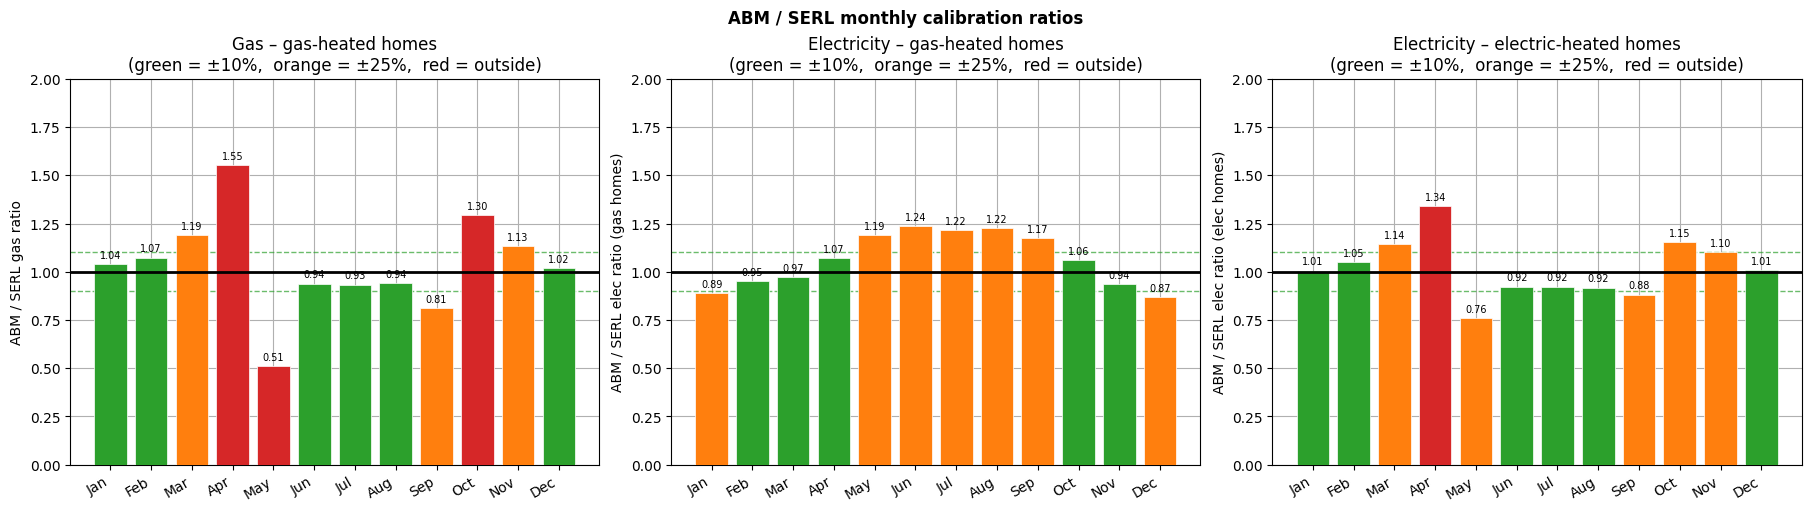


All outputs written to: /Users/abeltran/Documents/GitHub/spdt_abm/results/calibration_20260317_101305
Config YAML: /Users/abeltran/Documents/GitHub/spdt_abm/results/calibration_20260317_101305/calibrated_config.yaml


In [14]:
# Monthly ratio bar chart — 3 panels: gas | electricity (gas homes) | electricity (elec homes)

_panel_defs = [
    # (series_label,                          lo,   hi,   y_title)
    ('Gas – gas-heated homes',               0.9,  1.1, 'ABM / SERL gas ratio'),
    ('Electricity – gas-heated homes',       0.9,  1.1, 'ABM / SERL elec ratio (gas homes)'),
    ('Electricity – electric-heated homes',  0.9,  1.1, 'ABM / SERL elec ratio (elec homes)'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for ax, (label, lo, hi, y_title) in zip(axes, _panel_defs):
    z      = ratio_table[ratio_table['series'] == label].sort_values('month')
    ratios = z['ratio'].values

    bar_colors = [
        '#2ca02c' if lo <= r <= hi
        else '#ff7f0e' if 0.75 <= r <= 1.25
        else '#d62728'
        for r in ratios
    ]

    bars = ax.bar(range(1, 13), ratios, color=bar_colors, edgecolor='white', lw=0.5, zorder=3)
    ax.axhline(1.0, color='black', lw=2, zorder=4)
    ax.axhline(lo, color='#2ca02c', lw=1, ls='--', alpha=0.7)
    ax.axhline(hi, color='#2ca02c', lw=1, ls='--', alpha=0.7)

    ax.set_title(f'{label}\n(green = ±10%,  orange = ±25%,  red = outside)')
    ax.set_ylim(0, max(2.0, float(np.nanmax(ratios)) * 1.15))
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(_mlabels, rotation=30, ha='right')
    ax.set_ylabel(y_title)
    for bar, r in zip(bars, ratios):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{r:.2f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('ABM / SERL monthly calibration ratios', fontsize=12, fontweight='bold')
plt.savefig(OUT_DIR / 'monthly_ratio_calibrated.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nAll outputs written to:', OUT_DIR)
print('Config YAML:', yaml_path)

### 4b — Intraday shape validation

The ratio charts above check **level** (monthly kWh/home/day). This chart checks **shape** — does the model
produce the right intraday demand curve?

Each panel overlays:
- **SERL occupancy lines** (thin, coloured) — the empirical profiles the model was fitted to (same chart as Section 2c)
- **ABM annual** (solid black) — aggregate hourly output from the full calibration run, normalised to mean = 1.0
- **ABM winter Dec–Feb** (dashed blue) — intraday shape when space heating is active
- **ABM summer Jun–Aug** (dashed orange) — intraday shape when only appliances and hot water run

The SERL profiles are annual averages (no seasonal breakdown is available in the aggregated data), so they sit
between the winter and summer ABM curves. A well-calibrated model should show:
- Winter ABM peak higher in the morning (space heating pulling demand up at 06–08 h) than the annual SERL line
- Summer ABM flatter and closer to 1.0 throughout the day
- Annual ABM tracking the SERL aggregate line within ±10%


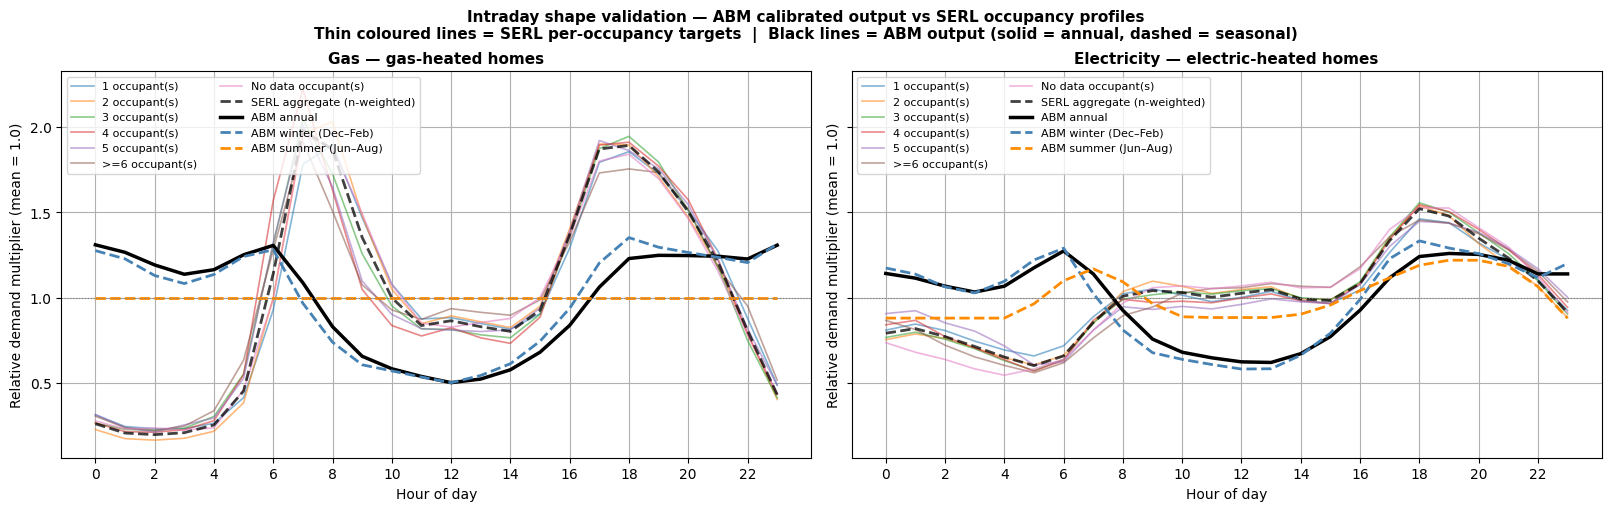

In [15]:
# ── 4b: Hourly profile validation — ABM calibrated shape vs SERL ─────────────
#
# Uses cal_seg_ts (full-year calibration run) split by central_heating_type
# to get fuel-bucket-specific hourly profiles. No new simulation needed.

# ── ABM: hourly profiles by season and fuel ───────────────────────────────────
_hv = cal_seg_ts.copy()
_hv['timestamp_utc'] = pd.to_datetime(_hv['timestamp_utc'], utc=True)
_hv_loc = _hv['timestamp_utc'].dt.tz_convert('Europe/London')
_hv['hour']      = _hv_loc.dt.hour
_hv['month_loc'] = _hv_loc.dt.month

_cht = _hv[_hv['segmentation'].astype(str) == 'central_heating_type'].copy()
_cht_gas  = _cht[_cht['value'].astype(str).str.contains('gas',  case=False, na=False)]
_cht_elec = _cht[~_cht['value'].astype(str).str.contains('gas', case=False, na=False)
                 & (_cht['value'].astype(str) != 'No data')]

_HV_SEASONS = {
    'annual':  list(range(1, 13)),
    'winter':  [12, 1, 2],
    'summer':  [6, 7, 8],
}

def _abm_norm_profile(df, kwh_col, months):
    """Mean kWh/home/hour per hour-of-day for given months, normalised to mean=1.0."""
    sub = df[df['month_loc'].isin(months)]
    agg = sub.groupby('hour', as_index=False).agg(
        total_kwh=(kwh_col,   'sum'),
        total_n  =('n_homes', 'sum'),
    )
    agg['kwh_per_home'] = agg['total_kwh'] / agg['total_n'].replace({0: np.nan})
    mu = agg['kwh_per_home'].mean()
    agg['mult'] = agg['kwh_per_home'] / mu if (mu and np.isfinite(mu)) else np.nan
    return agg.sort_values('hour')

abm_hv = {}
for season, months in _HV_SEASONS.items():
    abm_hv[('gas',      season)] = _abm_norm_profile(_cht_gas,  'gas_kwh',      months)
    abm_hv[('electric', season)] = _abm_norm_profile(_cht_elec, 'electric_kwh', months)

# ── SERL: n-weighted aggregate profile across all occupancy groups ────────────
def _serl_agg_norm(raw_df, fuel_label):
    """n-weighted mean kWh/home/hour per hour-of-day, normalised to mean=1.0."""
    sub = raw_df[raw_df['fuel'] == fuel_label].copy()
    sub['n'] = pd.to_numeric(sub['n'], errors='coerce').fillna(0)
    sub['wx'] = sub['kwh'] * sub['n']
    agg = sub.groupby('hour', as_index=False).agg(wx=('wx', 'sum'), n=('n', 'sum'))
    agg['kwh'] = agg['wx'] / agg['n'].replace({0: np.nan})
    mu = agg['kwh'].mean()
    agg['mult'] = agg['kwh'] / mu
    return agg.sort_values('hour')

serl_agg_gas  = _serl_agg_norm(raw_all, 'gas')
serl_agg_elec = _serl_agg_norm(raw_all, 'electric')

# ── Plot ──────────────────────────────────────────────────────────────────────
_HV_FUEL_DEFS = [
    ('gas',      'Gas — gas-heated homes',          serl_agg_gas),
    ('electric', 'Electricity — electric-heated homes', serl_agg_elec),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True, sharey=True)

_occ_cmap   = plt.get_cmap('tab10')
_occ_order  = [s for s in ['1', '2', '3', '4', '5', '>=6', 'No data'] if s in profile_segs]
_occ_colors = {seg: _occ_cmap(i) for i, seg in enumerate(_occ_order)}

for ax, (fuel, title, serl_agg) in zip(axes, _HV_FUEL_DEFS):
    # ── SERL: per-occupancy lines (same as Section 2c chart) ─────────────────
    prof_f = profiles_df[profiles_df['fuel'] == fuel]
    for seg in _occ_order:
        grp = prof_f[prof_f['seg3_value'] == seg].sort_values('idx')
        if grp.empty:
            continue
        ax.plot(grp['idx'], grp['mult'], lw=1.2, alpha=0.55,
                color=_occ_colors[seg], label=f'{seg} occupant(s)')

    # ── SERL: n-weighted aggregate (single reference line) ────────────────────
    ax.plot(serl_agg['hour'], serl_agg['mult'],
            color='black', lw=2.0, ls='--', alpha=0.75, label='SERL aggregate (n-weighted)')

    # ── ABM: annual, winter, summer ───────────────────────────────────────────
    ann = abm_hv[(fuel, 'annual')]
    win = abm_hv[(fuel, 'winter')]
    sum_ = abm_hv[(fuel, 'summer')]

    ax.plot(ann['hour'],  ann['mult'],  color='black', lw=2.5, ls='-',  label='ABM annual')
    ax.plot(win['hour'],  win['mult'],  color='steelblue', lw=2.0, ls='--', label='ABM winter (Dec–Feb)')
    ax.plot(sum_['hour'], sum_['mult'], color='darkorange', lw=2.0, ls='--', label='ABM summer (Jun–Aug)')

    ax.axhline(1.0, color='grey', lw=0.8, ls=':')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Relative demand multiplier (mean = 1.0)')
    ax.set_xticks(range(0, 24, 2))
    ax.legend(fontsize=8, ncol=2, loc='upper left')

plt.suptitle(
    'Intraday shape validation — ABM calibrated output vs SERL occupancy profiles\n'
    'Thin coloured lines = SERL per-occupancy targets  |  '
    'Black lines = ABM output (solid = annual, dashed = seasonal)',
    fontsize=11, fontweight='bold',
)
plt.savefig(OUT_DIR / 'hourly_shape_validation.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 5: Multi-year validation

Two complementary checks that go beyond the calibration target:

| Check | Data source | What it tests |
|-------|-------------|---------------|
| **5a — SERL year-over-year** | SERL 2021–2023 monthly targets | Do calibrated parameters hold across years, or did we overfit to 2023? |
| **5b — DESNZ LSOA benchmark** | Official gov.uk meter statistics | Is total annual kWh/dwelling close to independently-measured consumption? |

SERL was used to **derive** the parameters (Sections 2–3). DESNZ was never seen during calibration — it is a fully independent out-of-sample check.

### What "good" looks like
- **SERL ratios**: all monthly bars inside ±10% green zone for all years tested.
- **DESNZ ratio**: ABM/DESNZ ≈ 1.0 ± 0.15 at city level. Larger deviations may reflect portfolio composition differences (SERL sample ≠ full city stock) rather than model error.

> **Note on sampling:** Section 5 simulations run with `MAX_HOMES_PER_CITY` homes (same as calibration). For LSOA-resolution DESNZ scatter plots with full stock coverage, see `energy-model-calibration.ipynb`.

### 5a — SERL year-over-year

Run the **same calibrated config** against SERL monthly targets for 2021 and 2022 (in addition to 2023 which was already run in Section 4). Each year uses that year's observed temperatures from the climate parquet, so the comparison tests whether the HDD slope and anchors generalise across different weather years — not just whether the regression fits.

In [16]:
# ── 5a: Multi-year SERL monthly ratio check ───────────────────────────────────

VALIDATION_YEARS = [2021, 2022, 2023]   # extend as SERL data permits

def _serl_monthly_yr(year: int):
    """Monthly kWh/home/day from SERL for a given target year."""
    def _sm(heating_fuel):
        sub = daily_targets[
            (daily_targets['period_type'].astype(str) == 'monthly')
            & (daily_targets['year'].astype(int)       == year)
            & (daily_targets['weekday_weekend'].astype(str) == 'both')
            & (daily_targets['heating_fuel'].astype(str)    == heating_fuel)
            & (daily_targets['has_pv'].astype(str).isin(['No', 'All']))
            & (daily_targets['seg3_var'].astype(str)        == 'none')
            & (daily_targets['quantity'].astype(str).isin(['Electricity imports', 'Gas']))
        ].copy()
        sub['n_rounded'] = pd.to_numeric(sub['n_rounded'], errors='coerce').fillna(0.0)
        sub['mean']      = pd.to_numeric(sub['mean'], errors='coerce')
        sub['wx']        = sub['mean'] * sub['n_rounded']
        agg = sub.groupby(['month', 'quantity'], as_index=False).agg(
            wx=('wx', 'sum'), n=('n_rounded', 'sum'))
        agg['serl_kwh_per_home_day'] = agg['wx'] / agg['n'].replace({0: np.nan})
        agg['fuel'] = agg['quantity'].map({'Electricity imports': 'electric', 'Gas': 'gas'})
        return agg[['month', 'fuel', 'serl_kwh_per_home_day']]
    return _sm('Gas'), _sm('Electric')


# Collect segmentation timeseries per year; reuse the 2023 run already in memory
all_seg_ts: dict[int, pd.DataFrame] = {TARGET_YEAR: cal_seg_ts}

for yr in VALIDATION_YEARS:
    if yr in all_seg_ts:
        print(f'{yr}: reusing existing run ({len(all_seg_ts[yr]):,} rows)')
        continue
    print(f'{yr}: running calibrated simulation...', end=' ', flush=True)
    ts = run_pooled_segmentations(
        repo_root=REPO_ROOT,
        target_year=yr,
        seg3_vars=SMOKE_SEG3_VARS,
        cities=CITIES,
        max_homes_per_city=MAX_HOMES_PER_CITY,
        seed=SEED,
        model_overrides=model_overrides,
        process_column_preferred=PROCESS_COLUMN_PREFERRED,
        n_procs=N_PROCS,
    )
    ts.to_csv(OUT_DIR / f'seg_ts_{yr}.csv', index=False)
    all_seg_ts[yr] = ts
    print(f'done ({len(ts):,} rows)')


# Compute monthly ratios for each year using the same 3-series logic as Section 4
_SERIES = [
    # (abm_col,                              serl_selector,        label)
    ('abm_gas_kwh_per_home_day',             lambda g, e: (g, 'gas'),      'Gas – gas-heated homes'),
    ('abm_elec_gas_homes_kwh_per_home_day',  lambda g, e: (g, 'electric'), 'Electricity – gas-heated homes'),
    ('abm_elec_elec_homes_kwh_per_home_day', lambda g, e: (e, 'electric'), 'Electricity – electric-heated homes'),
]

ratio_by_year: dict[int, pd.DataFrame] = {}
for yr in VALIDATION_YEARS:
    ts = all_seg_ts[yr]
    m_gas, m_elec = _serl_monthly_yr(yr)
    cal = build_monthly_abm(ts)
    rows = []
    for col, serl_fn, label in _SERIES:
        serl_ref, fuel_filter = serl_fn(m_gas, m_elec)
        abm = cal[['month', col]].rename(columns={col: 'abm_kwh'})
        ref = serl_ref[serl_ref['fuel'] == fuel_filter][['month', 'serl_kwh_per_home_day']]
        mrg = abm.merge(ref, on='month')
        mrg['ratio']  = mrg['abm_kwh'] / mrg['serl_kwh_per_home_day']
        mrg['series'] = label
        rows.append(mrg)
    ratio_by_year[yr] = pd.concat(rows, ignore_index=True)

print('\nMean ratios by year and series:')
for yr in sorted(ratio_by_year):
    for _, _, label in _SERIES:
        mean_r = ratio_by_year[yr][ratio_by_year[yr]['series'] == label]['ratio'].mean()
        print(f'  {yr}  {label:46s}  {mean_r:.3f}')

2021: running calibrated simulation... done (7,209,480 rows)
2022: running calibrated simulation... done (7,209,480 rows)
2023: reusing existing run (7,209,480 rows)
Gas  heating types : ['Gas boiler']
Elec heating types : ['District or community', 'Electric storage radiators', 'Oil, solid fuel or biomass', 'Other electric', 'Other or other mix']
Gas  heating types : ['Gas boiler']
Elec heating types : ['District or community', 'Electric storage radiators', 'Oil, solid fuel or biomass', 'Other electric', 'Other or other mix']
Gas  heating types : ['Gas boiler']
Elec heating types : ['District or community', 'Electric storage radiators', 'Oil, solid fuel or biomass', 'Other electric', 'Other or other mix']

Mean ratios by year and series:
  2021  Gas – gas-heated homes                          0.811
  2021  Electricity – gas-heated homes                  0.904
  2021  Electricity – electric-heated homes             0.836
  2022  Gas – gas-heated homes                          0.980
  20

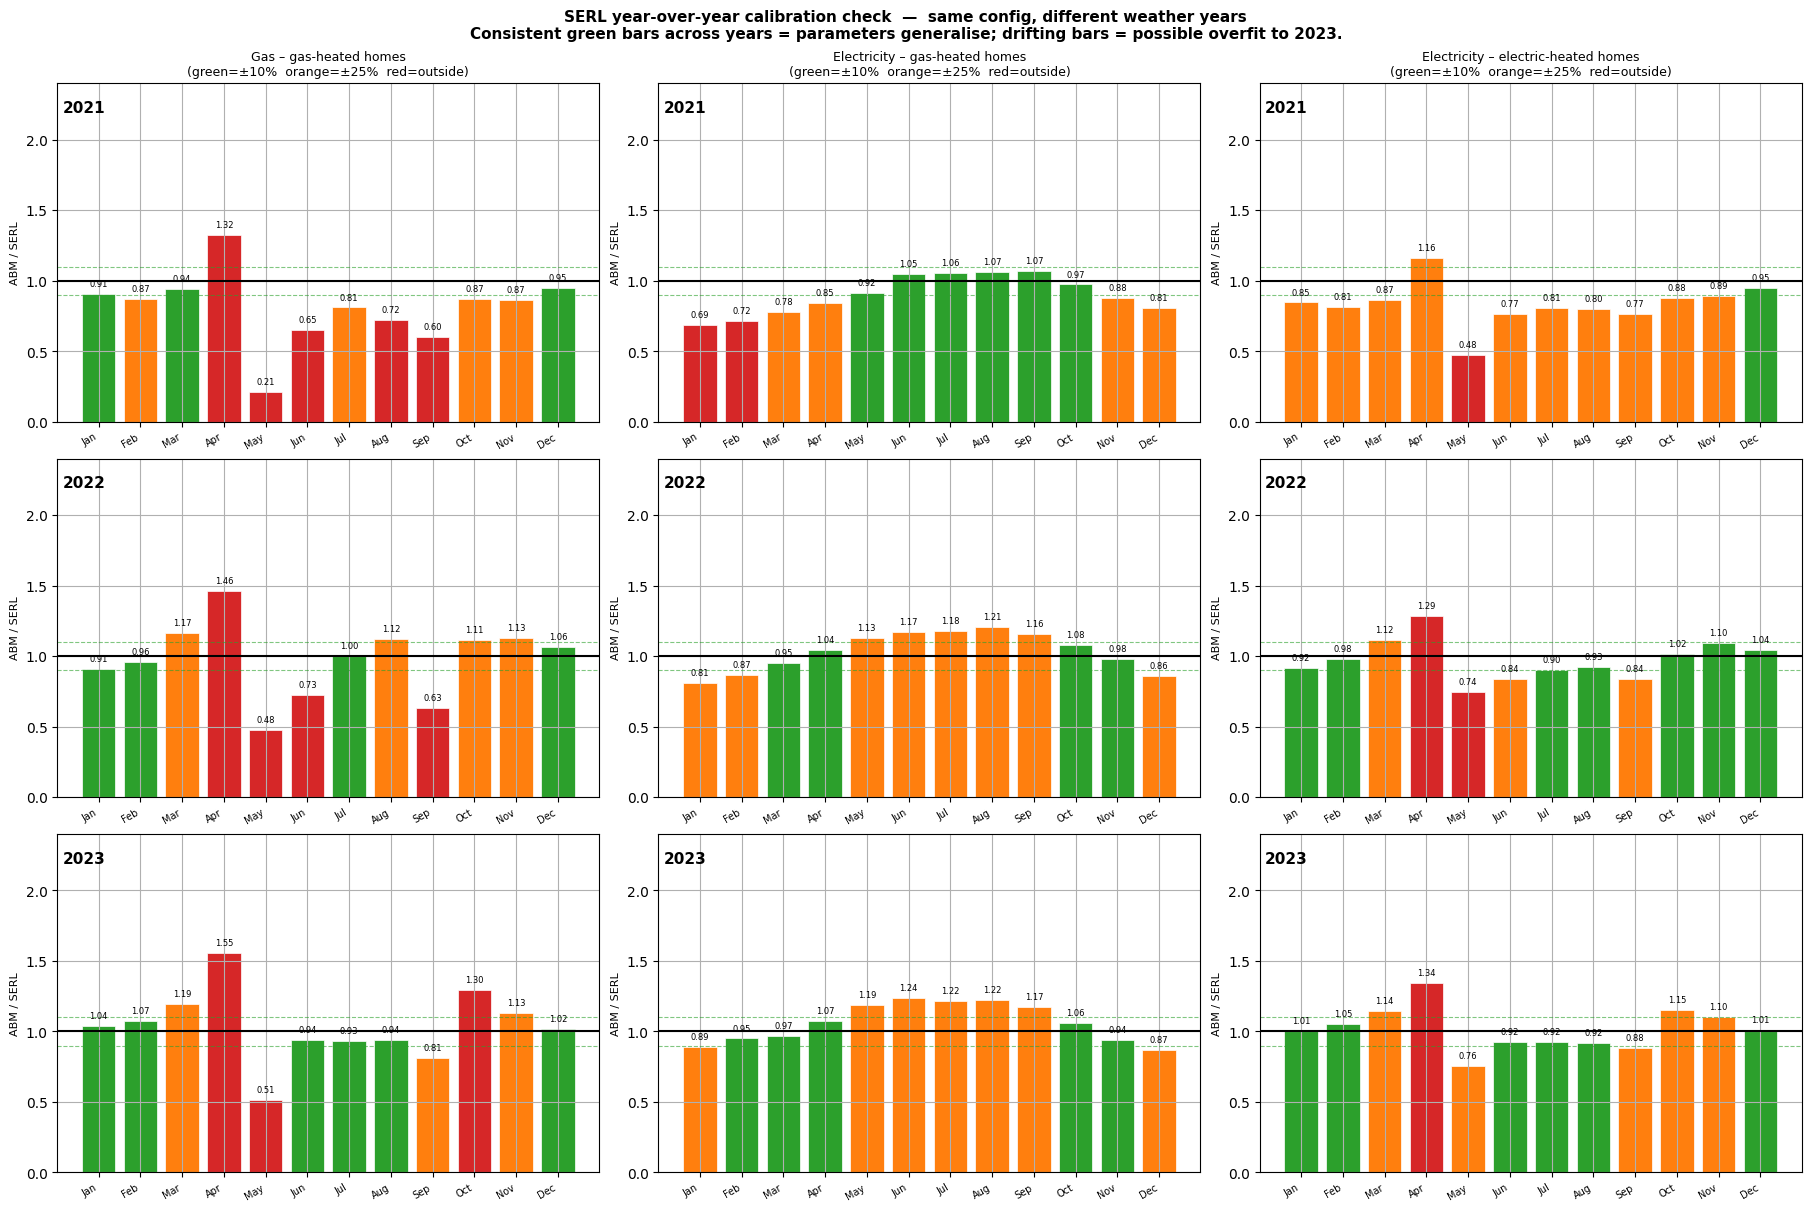

In [17]:
# Multi-year SERL ratio chart — rows = years, columns = 3 series

_series_labels = [s[2] for s in _SERIES]
_yrs = sorted(ratio_by_year)
fig, axes = plt.subplots(
    len(_yrs), 3,
    figsize=(18, 4 * len(_yrs)),
    constrained_layout=True,
    sharey='col',
)
if len(_yrs) == 1:
    axes = axes[np.newaxis, :]

for row_i, yr in enumerate(_yrs):
    rt = ratio_by_year[yr]
    for col_i, label in enumerate(_series_labels):
        ax = axes[row_i, col_i]
        z = rt[rt['series'] == label].sort_values('month')
        ratios = z['ratio'].values
        bar_colors = [
            '#2ca02c' if 0.9 <= r <= 1.1
            else '#ff7f0e' if 0.75 <= r <= 1.25
            else '#d62728'
            for r in ratios
        ]
        bars = ax.bar(range(1, 13), ratios, color=bar_colors, edgecolor='white', lw=0.5)
        ax.axhline(1.0, color='black', lw=1.5)
        ax.axhline(0.9, color='#2ca02c', lw=0.8, ls='--', alpha=0.6)
        ax.axhline(1.1, color='#2ca02c', lw=0.8, ls='--', alpha=0.6)
        ax.set_ylim(0, 2.4)
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(_mlabels, rotation=30, ha='right', fontsize=7)
        ax.set_ylabel('ABM / SERL', fontsize=8)
        if row_i == 0:
            ax.set_title(f'{label}\n(green=±10%  orange=±25%  red=outside)', fontsize=9)
        ax.annotate(str(yr), xy=(0.01, 0.95), xycoords='axes fraction',
                    fontsize=11, fontweight='bold', va='top')
        for bar, r in zip(bars, ratios):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.04,
                    f'{r:.2f}', ha='center', va='bottom', fontsize=6)

plt.suptitle(
    'SERL year-over-year calibration check  —  same config, different weather years\n'
    'Consistent green bars across years = parameters generalise; drifting bars = possible overfit to 2023.',
    fontsize=11, fontweight='bold',
)
plt.savefig(OUT_DIR / 'multiyear_serl_ratios.png', dpi=120, bbox_inches='tight')
plt.show()

### 5b — DESNZ independent benchmark

Compares ABM annual **total energy per dwelling** (gas + electricity) to the official DESNZ domestic energy statistics published by DBET. The data source is:

> *Lower and Middle Super Output Areas gas / electricity consumption* — [gov.uk/government/statistics/…](https://www.gov.uk/government/collections/sub-national-electricity-consumption-statistics)  
> Files expected at `data/LSOA_domestic_elec_2010-2023.xlsx` and `data/LSOA_domestic_gas_2010-2023.xlsx`

**Aggregation:** DESNZ city total kWh (elec + gas) ÷ DESNZ electricity meters  
**ABM equivalent:** sum hourly `gas_kwh + electric_kwh` across all building-type groups ÷ mean `n_homes`

A ratio of 1.0 means perfect agreement. Deviations up to ±20% are expected given:
- The ABM portfolio is a random subsample of EPC-registered homes, not the full city stock
- DESNZ meters include non-residential addresses that slip through geographic boundaries
- SERL calibration targets (used to set parameters) are national averages, not city-specific

In [18]:
# ── 5b: Load DESNZ domestic energy statistics ─────────────────────────────────

import re as _re

DESNZ_ELEC_XLSX = REPO_ROOT / 'data' / 'LSOA_domestic_elec_2010-2023.xlsx'
DESNZ_GAS_XLSX  = REPO_ROOT / 'data' / 'LSOA_domestic_gas_2010-2023.xlsx'

# Map ABM city names → DESNZ local_authority strings
_CITY_LA_MAP = {
    'newcastle':      'Newcastle upon Tyne',
    'sunderland':     'Sunderland',
    'waltham_forest': 'Waltham Forest',
}

# Column normalisation map — keys are post-whitespace-normalisation headers
# (DESNZ uses embedded newlines in headers; pd.read_excel + str.replace(r"\s+"," ") fixes them)
_DESNZ_COL_MAP = {
    'Local authority code':            'la_code',
    'Local authority':                 'local_authority',
    'MSOA code':                       'msoa_code',
    'Middle layer super output area':  'msoa_name',
    'LSOA code':                       'lsoa_code',
    'Lower layer super output area':   'lsoa_name',
    'Number of meters':                'meters',
    'Total consumption (kWh)':         'total_kwh',   # elec/gas sheets
    'Unmet consumption (kWh)':         'unmet_kwh',
}


def tidy_lsoa_desnz(xlsx_path: Path, fuel: str, years: list) -> pd.DataFrame:
    """Parse a DESNZ LSOA xlsx workbook (header on row 5, one sheet per year)."""
    if not xlsx_path.exists():
        return pd.DataFrame(columns=['year', 'fuel', 'lsoa_code', 'local_authority',
                                     'meters', 'total_kwh'])
    book = pd.read_excel(xlsx_path, sheet_name=None, header=4, engine='openpyxl')
    book.pop(next(iter(book)), None)   # drop cover/notes sheet
    frames = []
    for sheet_name, df in book.items():
        m = _re.search(r'(20\d{2})', str(sheet_name))
        if not m or int(m.group(1)) not in years:
            continue
        yr = int(m.group(1))
        df = df.copy()
        # Normalise embedded newlines / extra spaces in column headers
        df.columns = df.columns.astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()
        df = df.rename(columns={k: v for k, v in _DESNZ_COL_MAP.items() if k in df.columns})
        wanted = ['la_code', 'local_authority', 'lsoa_code', 'lsoa_name', 'meters', 'total_kwh']
        keep = [c for c in wanted if c in df.columns]
        if 'lsoa_code' not in keep or 'total_kwh' not in keep:
            continue
        df = df[keep].copy()
        for c in {'meters', 'total_kwh'} & set(keep):
            df[c] = pd.to_numeric(
                df[c].astype(str).str.replace(',', '', regex=False), errors='coerce')
        df['year'] = yr
        df['fuel'] = fuel
        df = df[~df['lsoa_code'].astype(str).str.contains('unallocated', case=False, na=False)]
        frames.append(df)
    if not frames:
        return pd.DataFrame(columns=['year', 'fuel', 'lsoa_code', 'local_authority',
                                     'meters', 'total_kwh'])
    out = pd.concat(frames, ignore_index=True)
    cols = [c for c in ['year', 'fuel', 'la_code', 'local_authority', 'lsoa_code',
                         'lsoa_name', 'meters', 'total_kwh'] if c in out.columns]
    return out[cols].reset_index(drop=True)


if DESNZ_ELEC_XLSX.exists():
    desnz_elec = tidy_lsoa_desnz(DESNZ_ELEC_XLSX, 'elec', VALIDATION_YEARS)
    desnz_gas  = tidy_lsoa_desnz(DESNZ_GAS_XLSX,  'gas',  VALIDATION_YEARS)
    print(f'DESNZ loaded:  elec={len(desnz_elec):,} rows  gas={len(desnz_gas):,} rows')
    print(f'Years:         {sorted(desnz_elec["year"].unique())}')
    print(f'LSOAs (elec):  {desnz_elec["lsoa_code"].nunique():,}')
    if 'local_authority' in desnz_elec.columns:
        print(f'Sample LAs:    {sorted(desnz_elec["local_authority"].dropna().unique())[:6]}')
else:
    desnz_elec = desnz_gas = None
    print(f'DESNZ files not found — skipping Section 5b.')
    print(f'Expected at:  {DESNZ_ELEC_XLSX}')
    print('Download from: https://www.gov.uk/government/collections/'
          'sub-national-electricity-consumption-statistics')

DESNZ loaded:  elec=127,944 rows  gas=127,944 rows
Years:         [np.int64(2021), np.int64(2022), np.int64(2023)]
LSOAs (elec):  42,648
Sample LAs:    ['Aberdeen City', 'Aberdeenshire', 'Adur', 'Amber Valley', 'Angus', 'Argyll and Bute']


In [19]:
# ── 5b: City-level DESNZ vs ABM comparison ────────────────────────────────────
#
# ABM source: the same calibration runs already computed above (MAX_HOMES_PER_CITY
#   homes, random sample of Newcastle EPC stock). We compare kWh/DWELLING RATE,
#   not totals — so sample size doesn't matter provided the sample is representative.
#
# DESNZ source: all domestic meters in Newcastle upon Tyne LA.
#   Denominator = electricity meters only (standard convention; used as dwelling proxy).
#
# What this tests: does the ABM's per-home annual energy budget match the
#   real-world city average — even though the model was calibrated to SERL
#   (a national panel), not to Newcastle specifically?

if desnz_elec is not None:
    # Filter DESNZ to local authorities matching the ABM cities
    _target_las = [_CITY_LA_MAP[c] for c in CITIES if c in _CITY_LA_MAP]
    _la_lower   = [la.lower() for la in _target_las]

    def _la_filter(df: pd.DataFrame) -> pd.DataFrame:
        if 'local_authority' not in df.columns:
            return df
        return df[df['local_authority'].astype(str).str.lower().isin(_la_lower)]

    desnz_e_city = _la_filter(desnz_elec)
    desnz_g_city = _la_filter(desnz_gas)
    print(f'DESNZ scope:  LA = {_target_las}')
    print(f'  elec: {desnz_e_city["lsoa_code"].nunique():,} LSOAs  '
          f'  gas: {desnz_g_city["lsoa_code"].nunique():,} LSOAs')

    # ── DESNZ: city-level annual kWh / elec-meter ────────────────────────────
    desnz_rows = []
    for yr in VALIDATION_YEARS:
        e_yr = desnz_e_city[desnz_e_city['year'] == yr]
        g_yr = desnz_g_city[desnz_g_city['year'] == yr]
        if e_yr.empty:
            continue
        total_elec  = float(e_yr['total_kwh'].sum())
        total_gas   = float(g_yr['total_kwh'].sum()) if not g_yr.empty else 0.0
        elec_meters = float(e_yr['meters'].sum())
        desnz_rows.append({
            'year':              yr,
            'desnz_elec_kwh':   total_elec,
            'desnz_gas_kwh':    total_gas,
            'desnz_total_kwh':  total_elec + total_gas,
            'desnz_meters':     elec_meters,
            'desnz_kwh_per_dw': (total_elec + total_gas) / elec_meters
                                 if elec_meters > 0 else np.nan,
        })
    desnz_summary = pd.DataFrame(desnz_rows)

    # ── ABM: kWh/dwelling from calibration runs ──────────────────────────────
    # Sum building_type groups per timestamp to get city-wide hourly totals.
    # Each home belongs to exactly one building_type, so this avoids double-counting.
    # avg_n = mean homes modelled per hour = the MAX_HOMES_PER_CITY sample size.
    abm_rows = []
    for yr, ts in sorted(all_seg_ts.items()):
        if yr not in VALIDATION_YEARS:
            continue
        bt = ts[ts['segmentation'].astype(str) == 'building_type'].copy()
        bt['timestamp_utc'] = pd.to_datetime(bt['timestamp_utc'], utc=True)
        city_hourly = bt.groupby('timestamp_utc', as_index=False).agg(
            total_gas=('gas_kwh',      'sum'),
            total_elec=('electric_kwh', 'sum'),
            total_n=('n_homes',         'sum'),
        )
        annual_kwh = float((city_hourly['total_gas'] + city_hourly['total_elec']).sum())
        avg_n      = float(city_hourly['total_n'].mean())
        abm_rows.append({
            'year':           yr,
            'abm_n_homes':    round(avg_n),        # homes modelled (the random sample)
            'abm_total_kwh':  annual_kwh,
            'abm_kwh_per_dw': annual_kwh / avg_n if avg_n > 0 else np.nan,
        })
    abm_summary = pd.DataFrame(abm_rows)

    # ── Merge and print ───────────────────────────────────────────────────────
    cmp_city = abm_summary.merge(desnz_summary, on='year', how='inner')
    cmp_city['ratio'] = cmp_city['abm_kwh_per_dw'] / cmp_city['desnz_kwh_per_dw']
    cmp_city.to_csv(OUT_DIR / 'desnz_city_comparison.csv', index=False)

    print(f'\nABM homes modelled: {abm_summary["abm_n_homes"].iloc[0]:,}  '
          f'(MAX_HOMES_PER_CITY={MAX_HOMES_PER_CITY}, random EPC sample)')
    print(f'DESNZ elec meters:  {int(desnz_summary["desnz_meters"].iloc[0]):,}  '
          f'(all domestic meters in LA — full city)')
    print(f'\nComparing per-dwelling RATES (kWh/home/year), not totals:\n')

    display(
        cmp_city[['year', 'abm_n_homes', 'desnz_meters',
                  'abm_kwh_per_dw', 'desnz_kwh_per_dw', 'ratio']]
        .rename(columns={
            'abm_n_homes':    'ABM homes',
            'desnz_meters':   'DESNZ meters',
            'abm_kwh_per_dw': 'ABM kWh/home',
            'desnz_kwh_per_dw': 'DESNZ kWh/meter',
            'ratio':          'ABM/DESNZ',
        })
        .round(0)
        .style.format({'ABM/DESNZ': '{:.3f}'})
        .set_caption('City-level: ABM sample rate vs DESNZ full-city rate')
    )
else:
    cmp_city = pd.DataFrame()
    print('DESNZ not loaded — cell skipped.')

DESNZ scope:  LA = ['Newcastle upon Tyne']
  elec: 180 LSOAs    gas: 180 LSOAs

ABM homes modelled: 1,500  (MAX_HOMES_PER_CITY=1500, random EPC sample)
DESNZ elec meters:  130,638  (all domestic meters in LA — full city)

Comparing per-dwelling RATES (kWh/home/year), not totals:



,year,ABM homes,DESNZ meters,ABM kWh/home,DESNZ kWh/meter,ABM/DESNZ
0,2021,1500,130638.000000,13775.000000,15250.000000,1.000
1,2022,1500,131035.000000,12909.000000,13433.000000,1.000
2,2023,1500,132253.000000,13154.000000,13712.000000,1.000


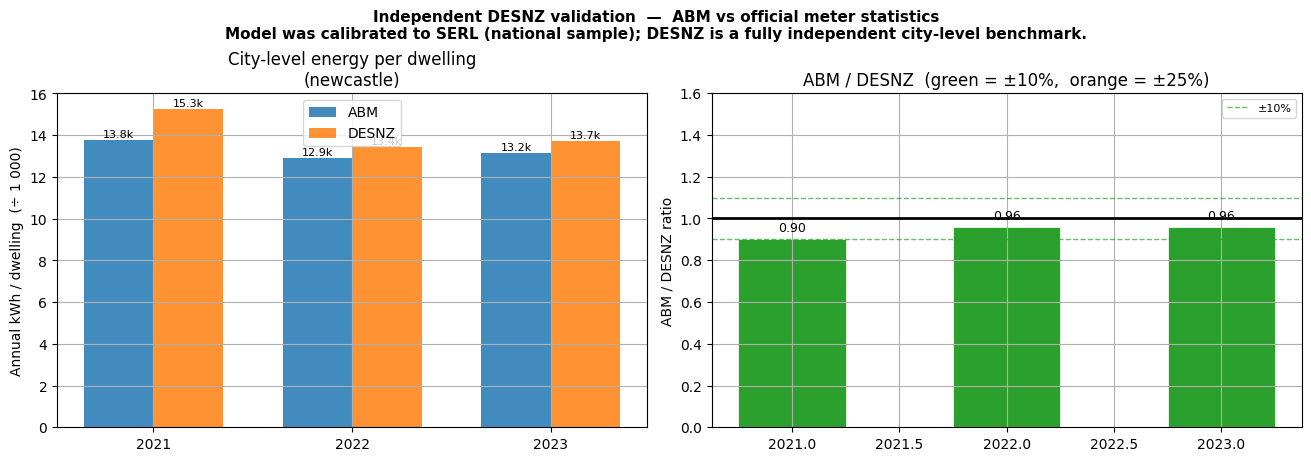

Section 5 complete. All outputs written to: /Users/abeltran/Documents/GitHub/spdt_abm/results/calibration_20260317_101305


In [20]:
# DESNZ validation charts

if not cmp_city.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

    # ── Left: grouped bar — ABM vs DESNZ per dwelling ────────────────────────
    ax = axes[0]
    x  = np.arange(len(cmp_city))
    w  = 0.35
    bars_abm   = ax.bar(x - w/2, cmp_city['abm_kwh_per_dw']   / 1e3, w,
                        label='ABM',   color='#1f77b4', alpha=0.85)
    bars_desnz = ax.bar(x + w/2, cmp_city['desnz_kwh_per_dw'] / 1e3, w,
                        label='DESNZ', color='#ff7f0e', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(cmp_city['year'].astype(int))
    ax.set_ylabel('Annual kWh / dwelling  (÷ 1 000)')
    ax.set_title(f'City-level energy per dwelling\n({", ".join(CITIES)})')
    ax.legend()
    for bar in list(bars_abm) + list(bars_desnz):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02,
                f'{h:.1f}k', ha='center', va='bottom', fontsize=8)

    # ── Right: ratio with ±10% / ±25% bands ──────────────────────────────────
    ax2 = axes[1]
    ratios = cmp_city['ratio'].values
    r_colors = ['#2ca02c' if 0.9 <= r <= 1.1
                else '#ff7f0e' if 0.75 <= r <= 1.25
                else '#d62728' for r in ratios]
    r_bars = ax2.bar(cmp_city['year'].astype(int), ratios,
                     color=r_colors, edgecolor='white', lw=0.5, width=0.5)
    ax2.axhline(1.0, color='black', lw=2)
    ax2.axhline(0.9, color='#2ca02c', lw=1, ls='--', alpha=0.7, label='±10%')
    ax2.axhline(1.1, color='#2ca02c', lw=1, ls='--', alpha=0.7)
    ax2.set_ylabel('ABM / DESNZ ratio')
    ax2.set_ylim(0, max(1.6, float(np.nanmax(ratios)) * 1.2))
    ax2.set_title('ABM / DESNZ  (green = ±10%,  orange = ±25%)')
    ax2.legend(fontsize=8)
    for bar, r in zip(r_bars, ratios):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f'{r:.2f}', ha='center', va='bottom', fontsize=9)

    plt.suptitle(
        'Independent DESNZ validation  —  ABM vs official meter statistics\n'
        'Model was calibrated to SERL (national sample); DESNZ is a fully independent city-level benchmark.',
        fontsize=11, fontweight='bold',
    )
    plt.savefig(OUT_DIR / 'desnz_city_validation.png', dpi=120, bbox_inches='tight')
    plt.show()

    print('Section 5 complete. All outputs written to:', OUT_DIR)

---
## Conclusion: what to do with the calibrated config

When this notebook has run to completion, everything you need is in `OUT_DIR` (printed at the top of Section 3):

```
results/calibration_YYYYMMDD_HHMMSS/
├── calibrated_config.yaml              ← the portable parameter file
├── calibrated_segmentation_timeseries.csv  ← 2023 validation run (raw hourly)
├── seg_ts_2021.csv                     ← 2021 validation run
├── seg_ts_2022.csv                     ← 2022 validation run
├── multiyear_serl_ratios.png           ← Section 5a chart
└── desnz_city_validation.png           ← Section 5b chart
```

### 1. Use the config in any model run

Load it via the `model_overrides` API (same mechanism used internally by this notebook):

```python
from household_energy.serl_calibration_v2 import run_pooled_segmentations
import yaml

with open('results/calibration_.../calibrated_config.yaml') as f:
    overrides = yaml.safe_load(f)

# Flatten nested keys for model_overrides (e.g. model.baseline_anchor_gas_kwh_per_hour)
flat = {}
for section, params in overrides.items():
    if isinstance(params, dict):
        for k, v in params.items():
            flat[f'{section}.{k}'] = v

seg_ts = run_pooled_segmentations(..., model_overrides=flat)
```

Or pass the YAML path directly to any CLI entrypoint that accepts `--override-yaml`.

### 2. Commit the config to version control

The YAML is self-contained and human-readable. Committing it means any collaborator can reproduce
calibrated runs without re-running the notebook:

```bash
cp results/calibration_.../calibrated_config.yaml household_energy/config_calibrated.yaml
git add household_energy/config_calibrated.yaml data/serl_profiles/serl_profiles_num_occupants.csv
git commit -m "chore: update calibrated config from SERL 2023 calibration run"
```

> The intraday profiles CSV (`data/serl_profiles/serl_profiles_num_occupants.csv`) must be committed
> alongside the YAML — the YAML references it by relative path.

### 3. Re-run calibration for a new year

Change `TARGET_YEAR` at the top of the notebook (cell-config) and re-run all cells.
All parameter derivations are fully automatic — no other changes are needed.

### 4. Scale up for production runs

`MAX_HOMES_PER_CITY = 1500` is a fast default suitable for calibration.
For production or LSOA-level analysis, increase it or set it to `None` to use the full EPC stock:

```python
MAX_HOMES_PER_CITY = None   # full stock — much slower, LSOA scatter becomes meaningful
```

### 5. Extend to additional cities

Add city names to the `CITIES` list (Section-config). Each city requires an LSOA-level EPC parquet
and climate parquet in the expected data paths. The calibrated parameters are national (SERL is a
national panel) so they transfer directly — no per-city re-calibration is needed.

### When to re-calibrate

| Trigger | Action |
|---------|--------|
| New SERL data release | Re-run notebook with updated `TARGET_YEAR` |
| Change to ABM thermal model | Re-derive slopes from Section 2b |
| New building-type categories added to EPC | Update `BTYPE_TO_CONFIG` map in Section 2a |
| Significant climate change scenario (post-2040) | Consider re-fitting HDD slopes on projected HDD data |
